# GradeScope — 04. Trening modeli i reguły symboliczne

**Cel:** trening 3 modeli ML (Pipeline: StandardScaler + model), porównanie metryk, ekstrakcja reguł decyzyjnych

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)
import pandas as pd

# Wczytanie danych
with open("../data/splits.pkl", "rb") as f:
    data = pickle.load(f)

with open("../data/selected_features.pkl", "rb") as f:
    selected_features = pickle.load(f)

X_train = data["X_train"][selected_features]
X_test  = data["X_test"][selected_features]
y_train = data["y_train"]
y_test  = data["y_test"]

print(f"Cechy: {len(selected_features)}, Train: {X_train.shape}, Test: {X_test.shape}")

Cechy: 12, Train: (5285, 12), Test: (1322, 12)


## 1. Definicja Pipeline'ów

In [2]:
# Każdy Pipeline = StandardScaler + model → eksportowany później jako jeden plik ONNX
pipelines = {
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  SVC(kernel="rbf", probability=True, random_state=42))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  GradientBoostingClassifier(n_estimators=100, random_state=42))
    ]),
}

print("Zdefiniowane Pipeline'y:", list(pipelines.keys()))

Zdefiniowane Pipeline'y: ['Random Forest', 'SVM', 'Gradient Boosting']


## 2. Trening i ocena modeli

In [3]:
results = {}

for name, pipeline in pipelines.items():
    print(f"Trening: {name}...", end=" ")
    pipeline.fit(X_train, y_train)
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_proba),
    }
    print("✓")

print("\nTrening zakończony.")

Trening: Random Forest... ✓
Trening: SVM... ✓
Trening: Gradient Boosting... ✓

Trening zakończony.


## 3. Porównanie metryk

                   Accuracy  Precision  Recall      F1  ROC-AUC
Random Forest        0.8933     0.8984  0.9141  0.9062   0.9568
SVM                  0.9077     0.9115  0.9262  0.9188   0.9698
Gradient Boosting    0.9047     0.9078  0.9248  0.9162   0.9658


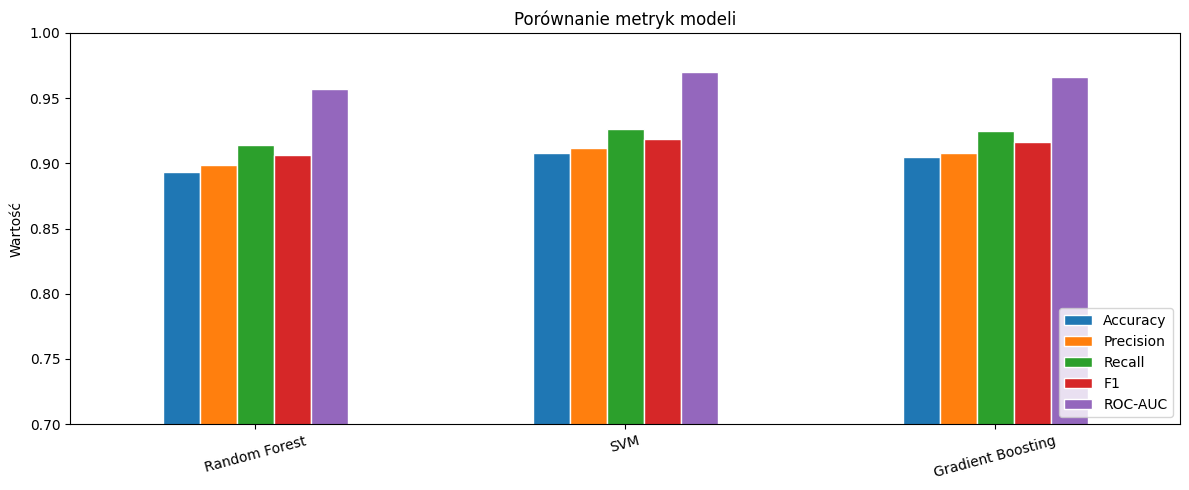

In [4]:
# Tabela porównawcza
df_results = pd.DataFrame(results).T.round(4)
print(df_results.to_string())

# Wykres słupkowy metryk
df_results.plot(kind="bar", figsize=(12, 5), edgecolor="white")
plt.title("Porównanie metryk modeli")
plt.ylabel("Wartość")
plt.xticks(rotation=15)
plt.ylim(0.7, 1.0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../report/fig_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Macierze pomyłek

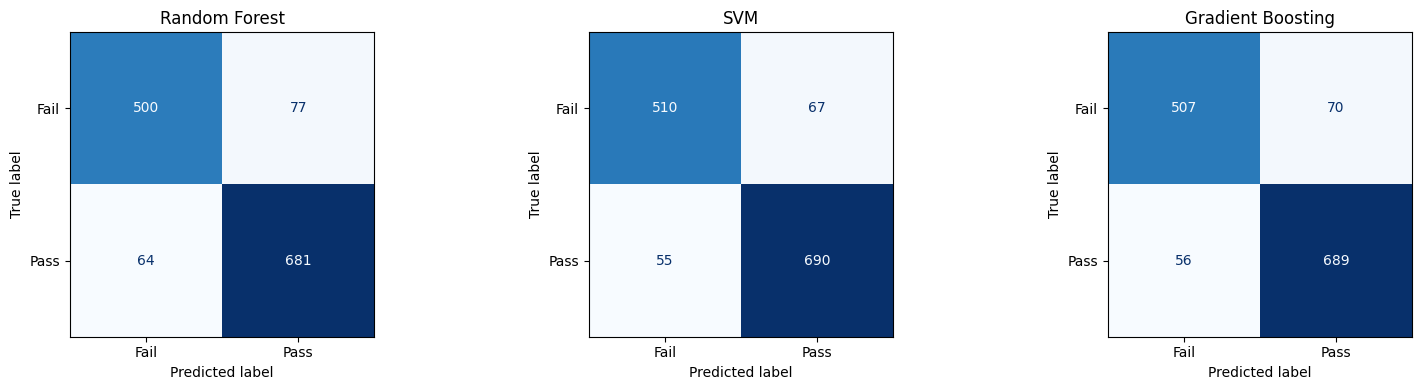

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, pipeline) in zip(axes, pipelines.items()):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Fail", "Pass"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)

plt.tight_layout()
plt.savefig("../report/fig_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Reguły symboliczne — drzewo decyzyjne

In [6]:
# Drzewo decyzyjne jako interpreter — shallow tree dla czytelnych reguł
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

dt_acc = accuracy_score(y_test, dt.predict(X_test))
print(f"Accuracy drzewa (max_depth=4): {dt_acc:.4f}\n")
print("Reguły decyzyjne:")
print(export_text(dt, feature_names=selected_features))

Accuracy drzewa (max_depth=4): 0.8245

Reguły decyzyjne:
|--- Attendance <= 79.50
|   |--- Hours_Studied <= 22.50
|   |   |--- Attendance <= 73.50
|   |   |   |--- Hours_Studied <= 17.50
|   |   |   |   |--- class: 0
|   |   |   |--- Hours_Studied >  17.50
|   |   |   |   |--- class: 0
|   |   |--- Attendance >  73.50
|   |   |   |--- Hours_Studied <= 16.50
|   |   |   |   |--- class: 0
|   |   |   |--- Hours_Studied >  16.50
|   |   |   |   |--- class: 0
|   |--- Hours_Studied >  22.50
|   |   |--- Attendance <= 72.50
|   |   |   |--- Hours_Studied <= 27.50
|   |   |   |   |--- class: 0
|   |   |   |--- Hours_Studied >  27.50
|   |   |   |   |--- class: 1
|   |   |--- Attendance >  72.50
|   |   |   |--- Previous_Scores <= 73.50
|   |   |   |   |--- class: 1
|   |   |   |--- Previous_Scores >  73.50
|   |   |   |   |--- class: 1
|--- Attendance >  79.50
|   |--- Hours_Studied <= 14.50
|   |   |--- Attendance <= 89.50
|   |   |   |--- Access_to_Resources <= 0.50
|   |   |   |   |--- cl

In [7]:
import json
from sklearn.tree import _tree

# Rekurencyjne wyodrębnienie reguł z drzewa decyzyjnego
def extract_rules(tree, feature_names):
    tree_ = tree.tree_
    rules = []

    def recurse(node, conditions):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            feature   = feature_names[tree_.feature[node]]
            threshold = round(float(tree_.threshold[node]), 2)
            recurse(tree_.children_left[node],  conditions + [{"feature": feature, "operator": "<=", "threshold": threshold}])
            recurse(tree_.children_right[node], conditions + [{"feature": feature, "operator": ">",  "threshold": threshold}])
        else:
            values     = tree_.value[node][0]
            total      = sum(values)
            prediction = int(np.argmax(values))
            confidence = round(float(max(values) / total), 4)
            rules.append({
                "conditions": conditions,
                "prediction": prediction,
                "confidence": confidence,
                "samples":    int(total),
            })

    recurse(0, [])
    return rules

rules = extract_rules(dt, selected_features)
print(f"Liczba reguł: {len(rules)}")

with open("../data/rules.json", "w") as f:
    json.dump(rules, f, indent=2)

print("Zapisano: data/rules.json")

Liczba reguł: 16
Zapisano: data/rules.json


## 6. Zapis modeli

In [8]:
# Zapis Pipeline'ów — do eksportu ONNX
model_keys = {
    "Random Forest":    "random_forest",
    "SVM":              "svm",
    "Gradient Boosting":"gradient_boosting",
}

with open("../data/trained_pipelines.pkl", "wb") as f:
    pickle.dump({model_keys[k]: v for k, v in pipelines.items()}, f)

with open("../data/decision_tree.pkl", "wb") as f:
    pickle.dump(dt, f)

print("Zapisano: trained_pipelines.pkl, decision_tree.pkl")

Zapisano: trained_pipelines.pkl, decision_tree.pkl
